Part 1: Create a custom multi-armed bandit environment that follows the Gymnasium API structure (implement reset() and step() methods). The bandit should have 10 arms with Gaussian reward distributions. Implement ε-greedy and UCB algorithms as agents using NumPy for numerical computations. Run 2000 time steps across 1000 independent runs. Plot average reward and optimal action percentage over time for each algorithm with multiple parameter settings (try ε ∈ {0.01, 0.1, 0.2} and different UCB confidence levels).

In [1]:
import numpy as np

class CustomBanditEnv:
    def __init__(self, arms=10):
        self.arms = arms
        self.reset()

    def reset(self):
        # Generate true reward values for each arm
        self.true_values = np.random.normal(0, 1, self.arms)
        self.best_arm = np.argmax(self.true_values)
        return None

    def step(self, action):
        reward = np.random.normal(self.true_values[action], 1)
        done = False
        return None, reward, done, {}

In [2]:
class EpsilonGreedy:
    def __init__(self, arms, epsilon):
        self.arms = arms
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        self.q_estimates = np.zeros(self.arms)
        self.action_counts = np.zeros(self.arms)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.arms)
        return np.argmax(self.q_estimates)

    def update(self, action, reward):
        self.action_counts[action] += 1
        alpha = 1 / self.action_counts[action]
        self.q_estimates[action] += alpha * (reward - self.q_estimates[action])

In [3]:
class UCB:
    def __init__(self, arms, c):
        self.arms = arms
        self.c = c
        self.reset()

    def reset(self):
        self.q_estimates = np.zeros(self.arms)
        self.action_counts = np.zeros(self.arms)
        self.time = 0

    def select_action(self):
        self.time += 1

        # Ensure each arm is selected at least once
        for i in range(self.arms):
            if self.action_counts[i] == 0:
                return i

        confidence = self.c * np.sqrt(np.log(self.time) / self.action_counts)
        ucb_values = self.q_estimates + confidence
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.action_counts[action] += 1
        alpha = 1 / self.action_counts[action]
        self.q_estimates[action] += alpha * (reward - self.q_estimates[action])

In [4]:
def simulate(agent_class, param, runs=1000, steps=2000):
    avg_rewards = np.zeros((runs, steps))
    optimal_rate = np.zeros((runs, steps))

    for r in range(runs):
        env = CustomBanditEnv()
        env.reset()

        agent = agent_class(10, param)
        agent.reset()

        for t in range(steps):
            action = agent.select_action()
            _, reward, _, _ = env.step(action)

            agent.update(action, reward)

            avg_rewards[r, t] = reward
            optimal_rate[r, t] = (action == env.best_arm)

    return avg_rewards.mean(axis=0), optimal_rate.mean(axis=0)

In [5]:
eps_values = [0.01, 0.1, 0.2]
ucb_values = [0.5, 1, 3]

results = {}

for eps in eps_values:
    results[f"EG_{eps}"] = simulate(EpsilonGreedy, eps)

for c in ucb_values:
    results[f"UCB_{c}"] = simulate(UCB, c)

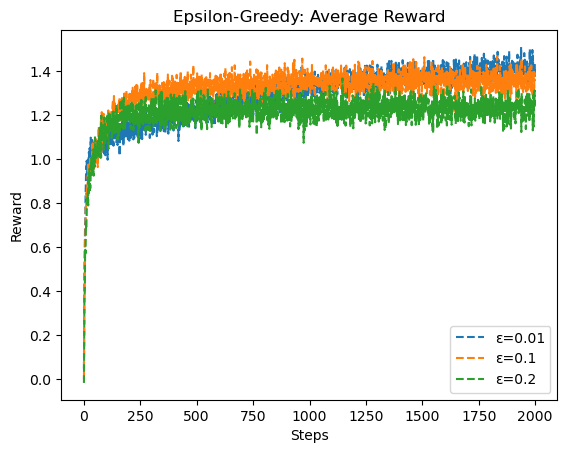

In [6]:
import matplotlib.pyplot as plt
plt.figure()

for eps in eps_values:
    rewards, _ = results[f"EG_{eps}"]
    plt.plot(rewards, linestyle='--', label=f"ε={eps}")

plt.title("Epsilon-Greedy: Average Reward")
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.legend()
plt.show()

The figure shows that all ε-greedy strategies improve rapidly at the beginning as they explore different actions, but their long-term performance differs. The ε = 0.1 setting achieves the best overall results, balancing exploration and exploitation effectively to reach higher and more stable rewards. In contrast, ε = 0.01 learns more slowly due to limited exploration, while ε = 0.2 performs worse over time because excessive exploration prevents it from consistently exploiting the optimal action.

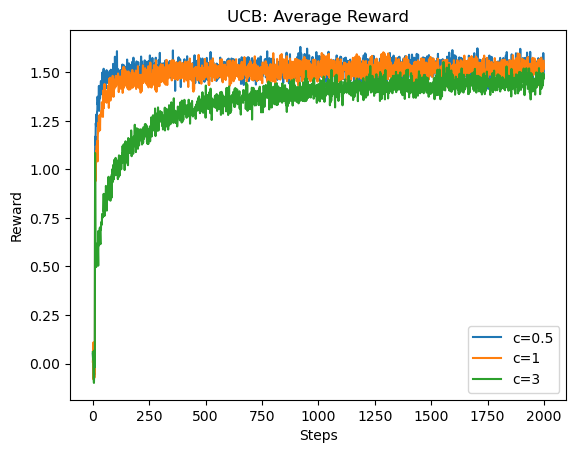

In [7]:
plt.figure()

for c in ucb_values:
    rewards, _ = results[f"UCB_{c}"]
    plt.plot(rewards, label=f"c={c}")

plt.title("UCB: Average Reward")
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.legend()
plt.show()

The figure shows that all UCB variants achieve rapid improvement early on, indicating efficient and structured exploration. The c = 0.5 and c = 1 settings perform the best, reaching higher average rewards quickly and remaining stable over time, with c = 0.5 slightly leading. In contrast, c = 3 performs worse overall because excessive exploration slows down convergence to the optimal action. Overall, 0.5 and 1  provide a better balance, allowing the agent to explore effectively while still exploiting high-reward actions.

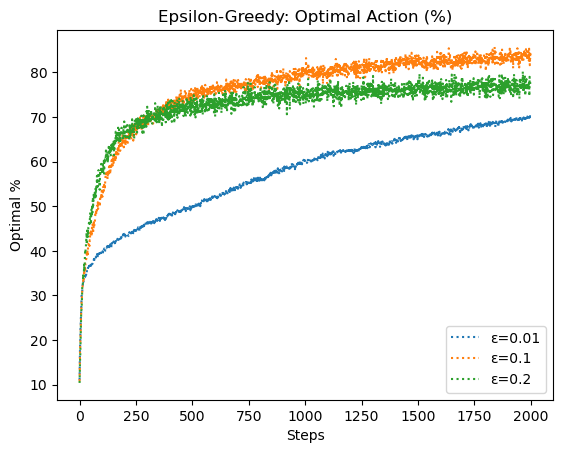

In [8]:
plt.figure()

for eps in eps_values:
    _, opt = results[f"EG_{eps}"]
    plt.plot(opt * 100, linestyle=':', label=f"ε={eps}")

plt.title("Epsilon-Greedy: Optimal Action (%)")
plt.xlabel("Steps")
plt.ylabel("Optimal %")
plt.legend()
plt.show()

This figure shows how often each ε-greedy strategy ends up picking the best action over time. The ε = 0.1 curve clearly does the best, steadily increasing and reaching the highest percentage, which means it finds and sticks with the optimal action more effectively. The ε = 0.2 line improves quickly at first but doesn’t quite reach the same level because it keeps exploring a bit too much. Meanwhile, ε = 0.01 takes longer to catch up since it doesn’t explore enough early on. Overall, it feels like ε = 0.1 hits that sweet spot between trying new things and sticking with what works.

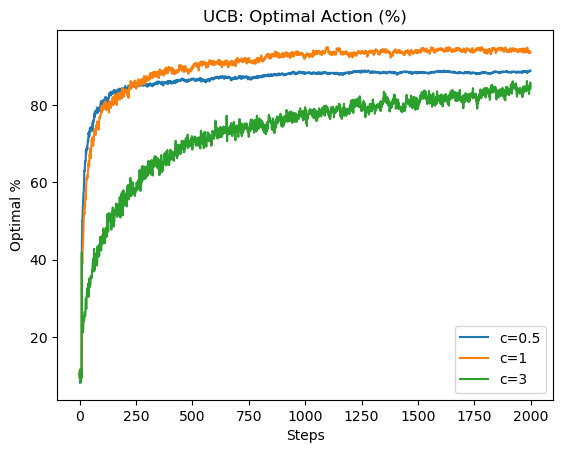

In [9]:
plt.figure()

for c in ucb_values:
    _, opt = results[f"UCB_{c}"]
    plt.plot(opt * 100, label=f"c={c}")

plt.title("UCB: Optimal Action (%)")
plt.xlabel("Steps")
plt.ylabel("Optimal %")
plt.legend()
plt.show()

This figure shows how often each UCB setting picks the optimal action over time. The c = 1 curve performs the best overall, quickly rising and reaching the highest percentage, which means it finds the best action and sticks with it more consistently. The c = 0.5 line is close behind, showing strong performance but slightly lower than c = 1. On the other hand, c = 3 improves more slowly and stays lower throughout because it keeps exploring too much. Overall, a moderate value like c = 1 seems to strike the right balance between exploring new options and exploiting the best one.

In [10]:
import gymnasium as gym

envs = ["FrozenLake-v1", "Taxi-v3"]

for name in envs:
    env = gym.make(name)

    print(f"\n{name}")
    print("Observation Space:", env.observation_space)
    print("Action Space:", env.action_space)

    env.close()


FrozenLake-v1
Observation Space: Discrete(16)
Action Space: Discrete(4)

Taxi-v3
Observation Space: Discrete(500)
Action Space: Discrete(6)


In [11]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state):
        return self.action_space.sample()

In [12]:
def evaluate_random(env_name, episodes=20):
    env = gym.make(env_name)
    agent = RandomAgent(env.action_space)

    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total = 0

        while not done:
            action = agent.act(state)
            state, reward, terminated, truncated, _ = env.step(action)

            total += reward
            done = terminated or truncated

        rewards.append(total)

    env.close()
    print(f"{env_name} Avg Reward: {np.mean(rewards):.2f}")

evaluate_random("FrozenLake-v1")
evaluate_random("Taxi-v3")

FrozenLake-v1 Avg Reward: 0.00
Taxi-v3 Avg Reward: -807.95
